# 建構 Agents
 
> 注意：在深入這份 notebook 之前，你可以選擇先看看[這份投影片](https://docs.google.com/presentation/d/13c0L1CQWAL7fuCXakOqjkvoodfynPJI4Hw_4H76okVU/edit?usp=sharing)以及 [langgraph_101.ipynb](langgraph_101.ipynb)，以建立背景概念！

我們將從零開始打造一個 email assistant，先從這裡的 1) agent 架構（使用 [LangGraph](https://langchain-ai.github.io/langgraph/)）開始，接著依序進行 2) 測試（使用 [LangSmith](https://docs.smith.langchain.com/)）、3) human-in-the-loop，以及 4) memory。下面這張圖顯示這些部分將如何拼在一起：

![overview-img](img/overview.png)

In [ ]:
# %pip install -e ..

#### 載入環境變數

In [1]:
from dotenv import load_dotenv
load_dotenv("../.env")

True

## Tool Definition

我們先用 `@tool` decorator 來定義一些 email assistant 將會用到的簡單 tools：

In [2]:
from typing import Literal
from datetime import datetime
from pydantic import BaseModel
from langchain_core.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """撰寫並寄出一封 email。"""
    # 佔位回應 - 真實應用中會實際寄出 email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

@tool
def schedule_meeting(
    attendees: list[str], subject: str, duration_minutes: int, preferred_day: datetime, start_time: int
) -> str:
    """在行事曆上排定一場會議。"""
    # 佔位回應 - 真實應用中會檢查行事曆並排程
    date_str = preferred_day.strftime("%A, %B %d, %Y")
    return f"Meeting '{subject}' scheduled on {date_str} at {start_time} for {duration_minutes} minutes with {len(attendees)} attendees"

@tool
def check_calendar_availability(day: str) -> str:
    """查詢某一天的行事曆空檔。"""
    # 佔位回應 - 真實應用中會檢查實際的行事曆
    return f"Available times on {day}: 9:00 AM, 2:00 PM, 4:00 PM"

# ⬇️ 這是本章最反直覺的一段，先講清楚再往下走。
#
# Done 是一個「什麼事都不做」的 tool：沒有邏輯、沒有副作用，
# 它存在的唯一目的，是讓 LLM 有辦法說一句「我做完了」。
#
# 為什麼要這樣搞？因為後面我們會用 bind_tools(..., tool_choice="any")，
# 強迫 LLM 每一輪都「一定要開一張工單」，不准直接講話。
# 既然不准講話，它就沒辦法用講的宣布結束 —— 只好也用開工單的方式講。
# Done 就是那張「收工單」。
#
# 類比：這間店的櫃檯只收單子、不聽人講話。師傅要下班，也得填一張「下班單」丟出來。
#
# 所以 tool_choice="any" 和 Done 是綁在一起的一組設計：
#   用了 tool_choice="any" ⟹ 一定要準備一個 Done 這種收工 tool，否則 agent 停不下來。
# 後面的 should_continue 就是看「這輪開的是不是 Done」來決定收不收工。
@tool
class Done(BaseModel):
      """Email 已寄出。"""
      done: bool

## 建構我們的 email assistant

我們會結合一個 [router 與 agent](https://langchain-ai.github.io/langgraph/tutorials/workflows/) 來打造這個 email assistant。

![agent_workflow_img](img/email_workflow.png)

### Router

Routing 這個步驟負責 triage（分類）的決策。

triage router 只專注於 triage 決策，而 agent 則*只*專注於回應。

#### State

在建構 agent 時，仔細思考你想隨時間追蹤哪些資訊是很重要的。我們會使用 LangGraph 預建的 [`MessagesState` object](https://langchain-ai.github.io/langgraph/concepts/low_level/#messagesstate)，它其實就是一個帶有 `messages` key 的 dictionary，其[更新邏輯](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers)會把各 node 回傳的 messages 附加進來。不過，LangGraph 也讓你能彈性地追蹤其他資訊。我們會定義一個自訂的 `State` object，它繼承 `MessagesState` 並加上一個 `classification_decision` key：

In [3]:
from langgraph.graph import MessagesState

# 繼承 MessagesState = 白拿一個現成的 messages 欄位，連 add_messages reducer 都附贈
# （node 回傳的 messages 是「附加」到既有那串後面，不是把整串蓋掉）。
# 自己從 TypedDict 寫的話，Annotated[list, add_messages] 這段要自己補，漏了就變成每次覆蓋。
#
# ⚠️ 踩雷：這裡寫的是「宣告」，不是「初始化」。沒人給 email_input，它就真的不存在，
#    node 裡 state["email_input"] 會 KeyError（實測過），不是拿到 None。
#    它是靠最後 invoke({"email_input": ...}) 從入口塞進來的。
class State(MessagesState):
    # 我們可以在 state 中加入一個專門存放 email 輸入的 key
    email_input: dict
    # triage 的判斷結果留在 state 裡：不只是紀錄。後面 evaluation 章節要拿它評分，
    # hitl 章節要拿它決定何時跳出來問人。
    classification_decision: Literal["ignore", "respond", "notify"]

#### Triage node

我們定義一個帶有 triage 路由邏輯的 Python 函式。

為此，我們搭配 Pydantic model 使用 [structured outputs](https://python.langchain.com/docs/concepts/structured_outputs/)，這對於定義 structured output 的 schema 特別有用，因為它提供了型別提示與驗證。Pydantic model 中的描述（description）很重要，因為它們會作為 JSON schema 的一部分傳給 LLM，用來引導輸出的轉換。

In [4]:

%load_ext autoreload
%autoreload 2

from pydantic import BaseModel, Field
from email_assistant.utils import parse_email, format_email_markdown
from email_assistant.prompts import triage_system_prompt, triage_user_prompt, default_triage_instructions, default_background
from langchain.chat_models import init_chat_model
from langgraph.graph import END
from langgraph.types import Command

In [5]:
from rich.markdown import Markdown
Markdown(triage_system_prompt)

< Role > Your role is to triage incoming emails based upon instructs and background information below. </ Role >   

< Background > {background}. </ Background >                                                                       

< Instructions > Categorize each email into one of three categories:                                               

 1 IGNORE - Emails that are not worth responding to or tracking                                                    
 2 NOTIFY - Important information that worth notification but doesn't require a response                           
 3 RESPOND - Emails that need a direct response Classify the below email into one of these categories. </          
   Instructions >                                                                                                  

< Rules > {triage_instructions} </ Rules >

In [6]:
Markdown(triage_user_prompt)

Please determine how to handle the below email thread:                                                             

From: {author} To: {to} Subject: {subject} {email_thread}

In [7]:
Markdown(default_background)

I'm Lance, a software engineer at LangChain.

In [8]:
Markdown(default_triage_instructions)

Emails that are not worth responding to:                                                                           

 • Marketing newsletters and promotional emails                                                                    
 • Spam or suspicious emails                                                                                       
 • CC'd on FYI threads with no direct questions                                                                    

There are also other things that should be known about, but don't require an email response. For these, you should 
notify (using the notify response). Examples of this include:                                                      

 • Team member out sick or on vacation                                                                             
 • Build system notifications or deployments                                                                       
 • Project status updates without action items                                                                     
 • Important company announcements                                                                                 
 • FYI emails that contain relevant information for current projects                                               
 • HR Department deadline reminders                                                                                
 • Subscription status / renewal reminders                                                                         
 • GitHub notifications                                                                                            

Emails that are worth responding to:                                                                               

 • Direct questions from team members requiring expertise                                                          
 • Meeting requests requiring confirmation                                                                         
 • Critical bug reports related to team's projects                                                                 
 • Requests from management requiring acknowledgment                                                               
 • Client inquiries about project status or features                                                               
 • Technical questions about documentation, code, or APIs (especially questions about missing endpoints or         
   features)                                                                                                       
 • Personal reminders related to family (wife / daughter)                                                          
 • Personal reminder related to self-care (doctor appointments, etc)

In [19]:
# with_structured_output(RouterSchema) = 把這個 schema 當一張「表格」丟給 LLM 填，
# 回來的 result 直接就是 RouterSchema 物件，result.classification 保證是那三個字串之一。
# 對照組：不用 structured output 的話，你得在 prompt 裡拜託它「請只回 respond/ignore/notify」，
# 然後自己 parse 它回的「Based on my analysis, I think we should respond.」—— parse 到死。
#
# ⭐ 為什麼 reasoning 排在 classification 前面？這是刻意的，不是隨手排的。
# structured output 是一個欄位一個欄位生成的，欄位順序 = 生成順序。
# reasoning 在前 ⟹ LLM 被迫先把推理寫出來，才落 classification 這一刀（先想再答）。
# 兩個欄位對調就變成先射箭再畫靶：先蹦一個答案出來，再回頭幫那個答案編理由，準確率會掉。
# 這是 structured output 很實用的小技巧：想讓它想清楚，就把思考欄位排前面。
class RouterSchema(BaseModel):
    """分析未讀 email，並依其內容進行路由。"""

    reasoning: str = Field(
        description="Step-by-step reasoning behind the classification."
    )
    classification: Literal["ignore", "respond", "notify"] = Field(
        description="The classification of an email: 'ignore' for irrelevant emails, "
        "'notify' for important information that doesn't need a response, "
        "'respond' for emails that need a reply",
    )

# 初始化要搭配 router / structured output 使用的 LLM
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_router = llm.with_structured_output(RouterSchema) 

# ⭐ 本章最重要的新概念：Command。
#
# 一個 node 回傳 Command(goto=..., update=...)，等於一次講兩件事：
#   update = 我要改 state 的哪些欄位（這件事跟平常 return dict 一樣）
#   goto   = 下一站去哪（這件事以前不歸 node 管）
#
# 對照組（下面 agent 那張圖用的就是舊寫法，等一下會看到）：
#   舊寫法  ：node 只回傳 state 更新；去哪裡另外寫一個路由函式（should_continue），
#            再用 add_conditional_edges(節點, 路由函式) 掛上去。
#            → 「判斷」和「照判斷走」被拆在兩個地方，改一邊常忘了改另一邊。
#   Command ：node 自己判斷、自己決定去向，兩件事寫在同一個 if/elif 裡。
#            → 這裡一眼就看得出「判成 respond 就去 response_agent」。
#
# ⚠️ 踩雷：-> Command[Literal["response_agent", "__end__"]] 這個型別註記不是裝飾品。
#    LangGraph 是「讀這行註記」才知道這個 node 可能往哪走，才畫得出線。
#    實測：拿掉註記程式照跑（goto 仍然有效），但畫出來的圖會少掉那條線 ——
#    圖跟實際行為不一致，而且不會拋任何例外。這種錯最難抓。
def triage_router(state: State) -> Command[Literal["response_agent", "__end__"]]:
    """分析 email 內容，判斷我們應該回覆、通知、還是忽略。"""
    
    author, to, subject, email_thread = parse_email(state["email_input"])
    system_prompt = triage_system_prompt.format(
        background=default_background,
        triage_instructions=default_triage_instructions
    )

    user_prompt = triage_user_prompt.format(
        author=author, to=to, subject=subject, email_thread=email_thread
    )

    result = llm_router.invoke(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt},
        ]
    )
    
    if result.classification == "respond":
        print("📧 Classification: RESPOND - This email requires a response")
        goto = "response_agent"
        # 這個 update 就是「交棒」：把 email 內容包成一則 user message 推進 messages。
        # response_agent 是另一張 graph，它醒來後看到的第一句話就是這則。
        # 換句話說，triage 交給下一棒的不是參數，是「對下一棒講的話」。
        update = {
            "messages": [
                {
                    "role": "user",
                    "content": f"Respond to the email: \n\n{format_email_markdown(subject, author, to, email_thread)}",
                }
            ],
            "classification_decision": result.classification,
        }
        
    elif result.classification == "ignore":
        print("🚫 Classification: IGNORE - This email can be safely ignored")
        goto = END
        # ignore / notify 這兩條路只記結論、不塞 messages —— goto=END，後面沒有人會去讀。
        update =  {
            "classification_decision": result.classification,
        }
        
    elif result.classification == "notify":
        print("🔔 Classification: NOTIFY - This email contains important information")
        # 目前先直接結束，之後會再擴充！
        # （後面 hitl 章節會在這個位置接上「跳出來通知人類」的分支。
        #   那時只要把 goto 改成新 node 的名字就好 —— 這就是把路由寫在 node 裡的好處。）
        goto = END
        update = {
            "classification_decision": result.classification,
        }
        
    else:
        raise ValueError(f"Invalid classification: {result.classification}")
    return Command(goto=goto, update=update)

我們在 LangGraph 中使用 [Command](https://langchain-ai.github.io/langgraph/how-tos/command/) object 來同時更新 state 並選擇接下來要造訪的 node。這是 edges 之外一個很有用的替代方案。

### Agent

現在，我們來建構這個 agent。

#### LLM node

在這裡，我們定義負責 LLM 決策的 node。這個 node 接收目前的 state、呼叫 LLM，並用 LLM 的輸出更新 `messages`。

我們透過設定 `tool_choice="required"` 來[強制 OpenAI 使用 tool](https://python.langchain.com/docs/how_to/tool_choice/)。

In [20]:
from email_assistant.tools.default.prompt_templates import AGENT_TOOLS_PROMPT
from email_assistant.prompts import agent_system_prompt, default_response_preferences, default_cal_preferences

In [21]:
Markdown(AGENT_TOOLS_PROMPT)

 1 write_email(to, subject, content) - Send emails to specified recipients                                         
 2 schedule_meeting(attendees, subject, duration_minutes, preferred_day, start_time) - Schedule calendar meetings  
   where preferred_day is a datetime object                                                                        
 3 check_calendar_availability(day) - Check available time slots for a given day                                   
 4 Done - E-mail has been sent

In [22]:
Markdown(agent_system_prompt)

< Role > You are a top-notch executive assistant who cares about helping your executive perform as well as         
possible. </ Role >                                                                                                

< Tools > You have access to the following tools to help manage communications and schedule: {tools_prompt} </     
Tools >                                                                                                            

< Instructions > When handling emails, follow these steps:                                                         

 1 Carefully analyze the email content and purpose                                                                 
 2 IMPORTANT --- always call a tool and call one tool at a time until the task is complete:                        
 3 For responding to the email, draft a response email with the write_email tool                                   
 4 For meeting requests, use the check_calendar_availability tool to find open time slots                          
 5 To schedule a meeting, use the schedule_meeting tool with a datetime object for the preferred_day parameter     
    • Today's date is 2026-07-17 - use this for scheduling meetings accurately                                     
 6 If you scheduled a meeting, then draft a short response email using the write_email tool                        
 7 After using the write_email tool, the task is complete                                                          
 8 If you have sent the email, then use the Done tool to indicate that the task is complete </ Instructions >      

< Background > {background} </ Background >                                                                        

< Response Preferences > {response_preferences} </ Response Preferences >                                          

< Calendar Preferences > {cal_preferences} </ Calendar Preferences >

In [23]:
# 收集所有 tools
tools = [write_email, schedule_meeting, check_calendar_availability, Done]
# ⭐ 前提揭露：LLM 不會執行任何 Python，它只會「說」它想呼叫哪個 tool（吐出一個名字字串）。
# 所以我們得自己準備一本電話簿：名字 → 真正的函式物件。
# 下面的 tool_handler 就是拿 LLM 給的名字來這本簿子查號，然後自己撥出去。
tools_by_name = {tool.name: tool for tool in tools}

# tool_choice="any" = 強迫 LLM 每一輪至少開一張工單，不准直接用講的回答。
# 好處：agent 的每一步都是可執行、可稽核的動作，不會混進「我覺得應該…」這種閒聊。
# 代價：它沒辦法用講話收工 —— 所以上面才需要 Done 那張收工單。這兩件事是一組的，
#       少了 Done，agent 就會被逼著一直開工單，停不下來。
#
# 補充：上面 markdown 寫 tool_choice="required"、程式碼寫 "any"，兩者是同一件事。
# "any" 是 LangChain 的跨供應商說法，送到 OpenAI 之前會被翻成 "required"（別家用 "any"）。
llm = init_chat_model("openai:gpt-4.1", temperature=0.0)
llm_with_tools = llm.bind_tools(tools, tool_choice="any")

def llm_call(state: State):
    """由 LLM 決定要不要呼叫 tool"""

    # system prompt 每次呼叫都現拼一份掛在最前面，不存進 state。
    # 所以 state["messages"] 裡永遠只有「對話本身」，改 prompt 不用動歷史紀錄。

    return {
        "messages": [
            # 呼叫 LLM
            llm_with_tools.invoke(
                # 加入 system prompt
                [   
                    {"role": "system", "content": agent_system_prompt.format(
                        tools_prompt=AGENT_TOOLS_PROMPT,
                        background=default_background,
                        response_preferences=default_response_preferences,
                        cal_preferences=default_cal_preferences, 
                    )}
                ]
                # 把目前的 messages 加到 prompt 中
                + state["messages"]
            )
        ]
    }

#### Tool handler node

在 LLM 做出決策之後，我們需要執行所選擇的 tool。

`tool_handler` 這個 node 會執行 tool。我們可以看到，nodes 能夠更新 graph 的 state，以便記錄任何重要的 state 變化，例如分類判斷。

In [24]:
def tool_handler(state: State):
    """執行 tool call。"""

    # 這是「手工版」的 ToolNode，把 tool calling 到底發生什麼事完整拆給你看：
    #   LLM 開工單（名字＋參數）→ 查電話簿拿到函式 → 我們自己執行 → 把結果寫回 messages。
    # LangGraph 有預建的 ToolNode 可以一行取代這整段；這裡故意手寫，
    # 因為後面 hitl 章節要在「執行之前」插入人工審核，用預建的就沒地方插手。

    # 存放 tool messages 的清單
    result = []
    
    # 逐一處理每個 tool call：LLM 一輪可以同時開好幾張工單
    for tool_call in state["messages"][-1].tool_calls:
        # 取得該 tool
        tool = tools_by_name[tool_call["name"]]
        # 執行它
        observation = tool.invoke(tool_call["args"])
        # 建立一則 tool message
        # ⚠️ 踩雷：tool_call_id 必須原封不動抄回去。LLM 靠這個 id 認「這份結果是回哪一張工單」。
        #    漏一張、或 id 對不上，下一輪 OpenAI 會直接回 400（有 tool_call 沒有對應的 tool message）——
        #    不是「答錯」，是整個請求被打回來。
        result.append({"role": "tool", "content" : observation, "tool_call_id": tool_call["id"]})
    
    # 把它加進我們的 messages
    return {"messages": result}

#### Conditional Routing

我們的 agent 需要決定何時要繼續使用 tools、何時要停止。這個 conditional routing 函式會引導 agent 繼續執行或終止。

In [25]:
def should_continue(state: State) -> Literal["tool_handler", "__end__"]:
    """路由到 tool handler，若呼叫了 Done tool 則結束。"""

    # 這是「舊寫法」的路由函式，剛好跟上面 triage_router 的 Command 成對照：
    # 它自己不改 state，只回傳「下一站的名字」，再由下面 add_conditional_edges 把名字接到 node。
    # Command 寫法則是 node 自己就把去向決定了，根本不需要這個函式。

    # ⚠️ 踩雷：以下這段是原始教材本身的 bug（官方 src/email_assistant/email_assistant.py
    #    也是同一份寫法，一起錯）。教學 demo 跑得過，抄進正式程式碼就是地雷。
    #
    #    問題 A：for 迴圈裡 if / else 兩條路都 return，所以這個迴圈永遠只跑第一圈，
    #           第二張以後的工單根本沒被看到。實測結果：
    #             tool_calls = [write_email, Done] → 回傳 "tool_handler"（Done 被無視）
    #             tool_calls = [Done, write_email] → 回傳 END
    #           同一份程式碼，工單順序不同結果就不同 —— 這叫「靠運氣正確」。
    #           demo 時之所以沒事，是因為 LLM 通常等事情做完才單獨開一張 Done。
    #
    #    問題 B：如果 last_message.tool_calls 是空的，函式一路走完什麼都沒 return → None。
    #           實測 LangGraph 會拋 KeyError: None（它拿 None 去查路由表）。
    #           tool_choice="any" 讓這件事在 demo 幾乎不會發生，但那是「幾乎」不是保證：
    #           換模型、或拿掉那個參數，就會炸。
    #
    #    上線要改成「先擋空的，再掃過全部工單」：
    #        if not last_message.tool_calls:
    #            return END
    #        return END if any(tc["name"] == "Done" for tc in last_message.tool_calls) else "tool_handler"
    #    這裡刻意保留原樣，方便跟原始教材對照。
    
    # 取得最後一則 message
    messages = state["messages"]
    last_message = messages[-1]
    
    # 檢查它是不是 Done tool call
    if last_message.tool_calls:
        for tool_call in last_message.tool_calls: 
            if tool_call["name"] == "Done":
                return END
            else:
                return "tool_handler"

#### Agent Graph

最後，我們可以把所有元件組裝起來：

In [26]:
from langgraph.graph import StateGraph, START, END
from email_assistant.utils import show_graph

# 建立 workflow
overall_workflow = StateGraph(State)

# 加入 nodes
overall_workflow.add_node("llm_call", llm_call)
overall_workflow.add_node("tool_handler", tool_handler)

# 加入 edges
overall_workflow.add_edge(START, "llm_call")
# ⭐ 這整段就是「舊寫法」的完整示範，拿來跟上面 triage_router 的 Command 對照著看：
# 路由邏輯（should_continue）和 node（llm_call）是分開的兩塊，得靠這個呼叫把它們接起來。
overall_workflow.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        # 左邊 = should_continue 可能回傳的字串，右邊 = 真正要去的 node 名字。
        # 這張對照表就是 Command 寫法省掉的東西（那邊 goto 直接寫 node 名字）。
        "tool_handler": "tool_handler",
        END: END,
    },
)
# tool 跑完無條件回到 llm_call —— 這條線就是 agent 之所以是 agent 的那個迴圈：
# 想 → 做 → 看結果 → 再想。唯一的出口是 LLM 開出 Done。
overall_workflow.add_edge("tool_handler", "llm_call")

# 編譯 agent
agent = overall_workflow.compile()

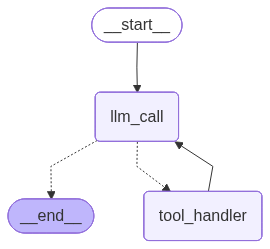

In [27]:
# 檢視
show_graph(agent)

這會建立一張這樣運作的 graph：
1. 從一次 LLM 決策開始
2. 依條件路由到 tool 執行或終止
3. 在 tool 執行之後，回到 LLM 進行下一次決策
4. 不斷重複，直到完成或沒有 tool 被呼叫為止

### 把 workflow 與我們的 agent 結合

我們可以把 router 與 agent 結合在一起。

In [28]:
overall_workflow = (
    StateGraph(State)
    # 只傳函式、不給名字 → node 名字自動取函式名，也就是 "triage_router"。
    # 下面 add_edge(START, "triage_router") 那個字串就是這樣對上的。
    .add_node(triage_router)
    # 把上面 compile 好的「整張 agent graph」當成一個 node 塞進來（sub-graph 巢狀）。
    # 對外它就是一個叫 response_agent 的普通 node，裡面 llm_call ↔ tool_handler 的迴圈被包起來。
    # 兩張 graph 共用同一個 State，所以 messages 直接接續，中間不用做任何轉換。
    .add_node("response_agent", agent)
    # ⚠️ 全圖只有這一條 edge。學員一定會問：triage_router 後面怎麼沒接線？
    # 因為它回傳 Command，去向自己就決定了 —— 這正是 Command 的重點：
    # 有 Command 的 node 不需要 edge，圖上那幾條線是 LangGraph 讀 Command[Literal[...]] 自己補的。
    .add_edge(START, "triage_router")
).compile()

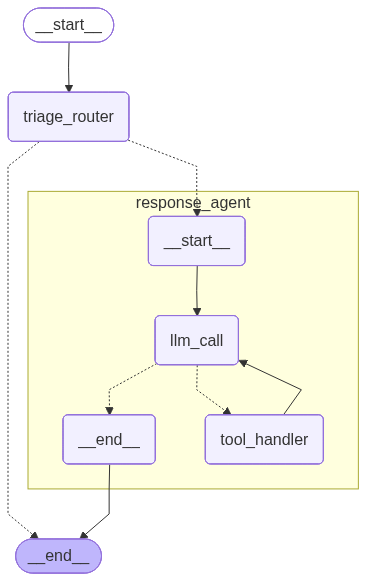

In [29]:
# xray=True 才會把 response_agent 這個 sub-graph 拆開，畫出裡面的 llm_call ↔ tool_handler 迴圈。
# 不加的話 response_agent 只會是一個方塊，看不出裡面有東西在轉。
show_graph(overall_workflow, xray=True)

這是一種更高層次的組合，其中：
1. 首先，triage router 會分析這封 email
2. 如有需要，response agent 會負責草擬一份回應
3. 當 triage 判斷不需要回應、或 response agent 完成工作時，整個 workflow 就結束

In [30]:
email_input = {
    "author": "System Admin <sysadmin@company.com>",
    "to": "Development Team <dev@company.com>",
    "subject": "Scheduled maintenance - database downtime",
    "email_thread": "Hi team,\n\nThis is a reminder that we'll be performing scheduled maintenance on the production database tonight from 2AM to 4AM EST. During this time, all database services will be unavailable.\n\nPlease plan your work accordingly and ensure no critical deployments are scheduled during this window.\n\nThanks,\nSystem Admin Team"
}

# 執行 agent
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

🔔 Classification: NOTIFY - This email contains important information


In [31]:
email_input = {
  "author": "Alice Smith <alice.smith@company.com>",
  "to": "John Doe <john.doe@company.com>",
  "subject": "Quick question about API documentation",
  "email_thread": "Hi John,\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\nThanks!\nAlice"
}

# 執行 agent
response = overall_workflow.invoke({"email_input": email_input})
for m in response["messages"]:
    m.pretty_print()

📧 Classification: RESPOND - This email requires a response
================================ Human Message =================================

Respond to the email: 



**Subject**: Quick question about API documentation
**From**: Alice Smith <alice.smith@company.com>
**To**: John Doe <john.doe@company.com>

Hi John,
I was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?
Specifically, I'm looking at:
- /auth/refresh
- /auth/validate
Thanks!
Alice

---

================================== Ai Message ==================================
Tool Calls:
  write_email (call_qxrHks2fQ3BkXkbUdLDnrYyt)
 Call ID: call_qxrHks2fQ3BkXkbUdLDnrYyt
  Args:
    to: alice.smith@company.com
    subject: Re: Quick question about API documentation
    content: Hi Alice,

Thank you for bringing this to my attention. I'll investigate whether the /auth/refre

## 用本機部署進行測試

你可以在 `src/email_assistant` 目錄中找到我們 agent 的檔案：

* `src/email_assistant/email_assistant.py`

你可以在 LangGraph Studio 中執行以下指令來進行本機測試：

```
! langgraph dev
```

你可以用來測試的範例 email：

In [ ]:
{
  "author": "Alice Smith <alice.smith@company.com>",
  "to": "John Doe <john.doe@company.com>",
  "subject": "Quick question about API documentation",
  "email_thread": "Hi John,\nI was reviewing the API documentation for the new authentication service and noticed a few endpoints seem to be missing from the specs. Could you help clarify if this was intentional or if we should update the docs?\nSpecifically, I'm looking at:\n- /auth/refresh\n- /auth/validate\nThanks!\nAlice"
}

![studio-img](img/studio.png)